# RQ2: Profit Erosion Concentration & Customer Segmentation

This notebook implements **Research Question 2 (RQ2)** of the Capstone project:

> **To what extent is profit erosion concentrated among a small subset of customers, and can customers be meaningfully segmented based on behavioral and erosion characteristics?**

The analysis proceeds in two phases:
1. **Concentration analysis** (Pareto, Lorenz curve, Gini coefficient)
2. **Customer segmentation** using unsupervised learning (K-Means clustering)

All outputs are generated from the processed, CI-safe dataset and saved for reproducibility.


## Step 1: Import Required Libraries

This setup cell centralizes imports for concentration analysis, clustering diagnostics, stability testing, and statistical significance checks.

In [1]:
import json
import sys
import time
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# Add project root to path (platform-independent)
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('Cannot find project root containing src directory.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import project modules
from src.config import PROCESSED_DATA_DIR
from src.feature_engineering import (
    aggregate_profit_erosion_by_customer,
    engineer_customer_behavioral_features,
)
from src.rq2_concentration import (
    compute_pareto_table,
    lorenz_curve_points,
    gini_coefficient,
    top_x_customer_share_of_value,
)
from src.rq2_segmentation import (
    build_customer_segmentation_table,
    select_numeric_features,
    standardize_features,
    kmeans_fit_predict,
    elbow_inertia_over_k,
    silhouette_over_k,
    clustering_metrics_over_k,
    compute_clustering_quality_metrics,
)

# Setup directories
rq2_output_dir = PROCESSED_DATA_DIR / 'rq2'
rq2_output_dir.mkdir(parents=True, exist_ok=True)

fig_dir = project_root / 'figures' / 'rq2'
fig_dir.mkdir(parents=True, exist_ok=True)

print(f'Project root: {project_root}')
print(f'Data outputs: {rq2_output_dir}')
print(f'Figure outputs: {fig_dir}')
print('Setup complete')


Project root: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project
Data outputs: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project\data\processed\rq2
Figure outputs: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project\figures\rq2
Setup complete


## Step 2: Load Processed Customer-Level Data

This step loads the **processed customer-level dataset** produced by earlier pipeline stages.

Key assumptions:
- All raw data cleaning and feature engineering have already been completed
- The dataset represents the **single source of truth** for RQ2 analysis
- No raw files are accessed (CI-safe execution)


In [2]:
# --- STEP 2: LOAD CUSTOMER-LEVEL DATA ---
processed_file = PROCESSED_DATA_DIR / 'customer_profit_erosion_targets.parquet'

if not processed_file.exists():
    raise FileNotFoundError(f'Required file not found: {processed_file}')

customer_erosion = pd.read_parquet(processed_file)
print(f'Loaded {len(customer_erosion):,} customer records')

required_columns = ['user_id', 'total_profit_erosion']
missing_cols = [col for col in required_columns if col not in customer_erosion.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

# Data quality checks
if customer_erosion['user_id'].duplicated().any():
    n_dupes = int(customer_erosion['user_id'].duplicated().sum())
    print(f'Warning: {n_dupes} duplicate user_ids found. Keeping first occurrence.')
    customer_erosion = customer_erosion.drop_duplicates(subset='user_id', keep='first')

numeric_cols = customer_erosion.select_dtypes(include=[np.number]).columns
if np.isinf(customer_erosion[numeric_cols].to_numpy()).any():
    print('Warning: Infinite numeric values found. Replacing with NaN then median-imputing.')
    customer_erosion[numeric_cols] = customer_erosion[numeric_cols].replace([np.inf, -np.inf], np.nan)
    customer_erosion[numeric_cols] = customer_erosion[numeric_cols].fillna(customer_erosion[numeric_cols].median())

analysis_df = customer_erosion[customer_erosion['total_profit_erosion'] > 0].copy()
if analysis_df.empty:
    raise ValueError('No customers with total_profit_erosion > 0. RQ2 concentration cannot be computed.')

print('Data quality summary:')
print(f'  Total records: {len(customer_erosion):,}')
print(f'  Missing values: {int(customer_erosion.isna().sum().sum())}')
print(f'  Duplicate IDs: {int(customer_erosion["user_id"].duplicated().sum())}')
print(f'  Customers with erosion > 0: {len(analysis_df):,}')


Loaded 11,790 customer records
Data quality summary:
  Total records: 11,790
  Missing values: 580
  Duplicate IDs: 0
  Customers with erosion > 0: 11,790


## Step 3: Validate Aggregate Profit Erosion Totals

Before proceeding, we verify that:
- Total profit erosion values are internally consistent
- Aggregated customer-level erosion matches prior pipeline outputs

This validation step prevents silent errors from propagating into
concentration metrics and clustering results.


In [3]:
# --- STEP 4: VERIFY SOURCE OF TRUTH TOTALS ---
# We use 'analysis_df' created in Cell 2 (customers with > 0 erosion)
total_erosion = analysis_df['total_profit_erosion'].sum()
customer_count = len(analysis_df)

print(f"📊 SUMMARY FROM CUSTOMER-LEVEL DATA:")
print(f"✓ Unique customers with returns: {customer_count:,}")
print(f"✓ Total Profit Erosion: ${total_erosion:,.2f}")

# Optional: verify other columns match your expectations
cols_to_check = ['total_margin_reversal', 'total_process_cost']
for col in cols_to_check:
    if col in analysis_df.columns:
        print(f"✓ {col.replace('_', ' ').title()}: ${analysis_df[col].sum():,.2f}")

📊 SUMMARY FROM CUSTOMER-LEVEL DATA:
✓ Unique customers with returns: 11,790
✓ Total Profit Erosion: $808,252.07
✓ Total Margin Reversal: $558,911.87
✓ Total Process Cost: $249,340.20


## Step 4: Construct Customer-Level Profit Erosion Summary

This step:
- Aggregates erosion metrics at the customer level
- Produces the base table used for both:
  - Concentration analysis
  - Segmentation modeling

The resulting dataset represents **customer economic impact**, not transaction volume.


In [4]:
# --- STEP 4: CUSTOMER EROSION SUMMARY ---
# We use 'analysis_df' from Cell 2 (already customer-level)
customer_erosion = analysis_df.sort_values('total_profit_erosion', ascending=False).reset_index(drop=True)

print(f"📊 CUSTOMER EROSION METRICS:")
print(f"  Customers with returns: {len(customer_erosion):,}")
print(f"  Total erosion: ${customer_erosion['total_profit_erosion'].sum():,.2f}")
print(f"  Mean erosion: ${customer_erosion['total_profit_erosion'].mean():.2f}")
print(f"  Median erosion: ${customer_erosion['total_profit_erosion'].median():.2f}")

# Save customer erosion for the RQ2 artifacts
customer_erosion.to_csv(rq2_output_dir / 'customer_erosion.csv', index=False)
customer_erosion.to_parquet(rq2_output_dir / 'customer_erosion.parquet', index=False)
print(f"\n✓ Saved customer_erosion artifacts to: {rq2_output_dir.name}")

customer_erosion.head(10)

📊 CUSTOMER EROSION METRICS:
  Customers with returns: 11,790
  Total erosion: $808,252.07
  Mean erosion: $68.55
  Median erosion: $47.52

✓ Saved customer_erosion artifacts to: rq2


,user_id,total_items,order_frequency,return_frequency,total_sales,total_margin,avg_item_price,avg_item_margin,customer_return_rate,avg_basket_size,purchase_recency_days,customer_tenure_days,avg_order_value,total_margin_reversal,total_process_cost,total_profit_erosion,erosion_percentile_rank,is_high_erosion_customer,profit_erosion_quartile
0,38929,4,1,4,1188.500000,666.809998,297.125000,166.702500,1.000000,4.00,206.0,260.0,1188.500000,666.809998,57.0,723.809998,100.000000,1,4
1,90574,9,4,5,1486.180004,771.480761,165.131112,85.720085,0.555556,2.25,328.0,575.0,371.545001,641.914120,72.6,714.514120,99.991518,1,4
2,16299,4,1,4,1109.549997,639.041157,277.387499,159.760289,1.000000,4.00,3.0,91.0,1109.549997,639.041157,58.8,697.841157,99.983036,1,4
3,89510,6,3,4,1230.930000,708.797808,205.155000,118.132968,0.666667,2.00,148.0,1379.0,410.310000,604.945808,57.0,661.945808,99.974555,1,4
4,11692,8,4,4,1466.970005,782.128161,183.371251,97.766020,0.500000,2.00,NaN,NaN,366.742501,585.446499,57.0,642.446499,99.966073,1,4
5,38754,6,3,4,1127.910004,604.665184,187.985001,100.777531,0.666667,2.00,1114.0,1906.0,375.970001,567.898833,53.4,621.298833,99.957591,1,4
6,52107,8,2,8,916.769996,512.380227,114.596249,64.047528,1.000000,4.00,404.0,1433.0,458.384998,512.380227,108.6,620.980227,99.949109,1,4
7,63348,5,2,4,1068.290002,547.549780,213.658000,109.509956,0.800000,2.50,782.0,2076.0,534.145001,542.830750,57.0,599.830750,99.940628,1,4
8,59667,7,4,4,1028.349998,592.006128,146.907143,84.572304,0.571429,1.75,NaN,NaN,257.087499,536.208448,60.6,596.808448,99.932146,1,4
9,31350,4,4,3,979.950001,574.256899,244.987500,143.564225,0.750000,1.00,396.0,1991.0,244.987500,547.661899,39.6,587.261899,99.923664,1,4


## Step 5: Compute Profit Erosion Concentration Metrics

This cell computes standard concentration measures, including:
- Pareto (top-X customer share)
- Lorenz curve points
- Gini coefficient

These metrics quantify whether profit erosion is:
- Broadly distributed, or
- Dominated by a small subset of customers


In [5]:
print('Calculating concentration metrics...')

pareto = compute_pareto_table(customer_erosion, value_col='total_profit_erosion')
lorenz = lorenz_curve_points(customer_erosion, value_col='total_profit_erosion')
gini = gini_coefficient(customer_erosion, value_col='total_profit_erosion')
top_10_share = top_x_customer_share_of_value(customer_erosion, x=0.10, value_col='total_profit_erosion')
top_20_share = top_x_customer_share_of_value(customer_erosion, x=0.20, value_col='total_profit_erosion')
top_50_share = top_x_customer_share_of_value(customer_erosion, x=0.50, value_col='total_profit_erosion')

print(f'  Gini coefficient: {gini:.3f}')
print(f'  Top 10% share: {top_10_share*100:.1f}%')
print(f'  Top 20% share: {top_20_share*100:.1f}%')
print(f'  Top 50% share: {top_50_share*100:.1f}%')

pareto.to_csv(rq2_output_dir / 'pareto_table.csv', index=False)
pareto.to_parquet(rq2_output_dir / 'pareto_table.parquet', index=False)
lorenz.to_csv(rq2_output_dir / 'lorenz_points.csv', index=False)
lorenz.to_parquet(rq2_output_dir / 'lorenz_points.parquet', index=False)
print('Saved concentration tables')


Calculating concentration metrics...
  Gini coefficient: 0.412
  Top 10% share: 30.3%
  Top 20% share: 47.6%
  Top 50% share: 78.2%
Saved concentration tables


## Outlier Influence Test on Profit Erosion Concentration

To assess whether profit erosion concentration is driven by a small number of extreme
customers or reflects a broader structural pattern, we recompute the Gini coefficient
after removing the top 1% of customers by total profit erosion.


In [6]:
# --- Outlier Influence Test: Remove Top 1% of Extreme Customers ---

from src.rq2_concentration import gini_coefficient

# 1) Compute baseline Gini directly (do NOT rely on external state)
gini_original = gini_coefficient(
    analysis_df,
    value_col="total_profit_erosion"
)

# 2) Determine cutoff for top 1% extreme customers
cutoff = analysis_df["total_profit_erosion"].quantile(0.99)

# 3) Filter out top 1%
analysis_trimmed = analysis_df[
    analysis_df["total_profit_erosion"] <= cutoff
].copy()

# 4) Recompute Gini after trimming
gini_trimmed = gini_coefficient(
    analysis_trimmed,
    value_col="total_profit_erosion"
)

# 5) Diagnostics
removed_customers = len(analysis_df) - len(analysis_trimmed)

print(f"Original Gini (full sample): {gini_original:.4f}")
print(f"Gini after removing top 1%: {gini_trimmed:.4f}")
print(f"Customers removed (top 1%): {removed_customers:,}")
print(f"Gini change: {gini_original - gini_trimmed:.4f}")


Original Gini (full sample): 0.4122
Gini after removing top 1%: 0.3897
Customers removed (top 1%): 118
Gini change: 0.0226


## Step 6: Engineer Customer Behavioral Features

This step constructs behavioral features such as:
- Order frequency
- Return frequency
- Monetary value indicators
- Return intensity metrics

These features capture **how customers behave**, not just how much erosion they generate.


In [7]:
# --- STEP 8: PREPARE BEHAVIORAL FEATURES ---
# Since we loaded the pre-calculated 'targets' file, the features are already there
customer_behavior = customer_erosion.copy()

print(f"📊 CUSTOMER BEHAVIORAL FEATURES:")
print(f"  Feature set shape: {customer_behavior.shape}")
print(f"  Total customers: {len(customer_behavior):,}")

# List the behavioral features available for clustering
behavioral_cols = [
    'order_frequency', 'total_sales', 'avg_item_price', 
    'customer_return_rate', 'customer_tenure_days'
]
existing_cols = [c for c in behavioral_cols if c in customer_behavior.columns]
print(f"✓ Available features for RQ2: {existing_cols}")

customer_behavior.head()

📊 CUSTOMER BEHAVIORAL FEATURES:
  Feature set shape: (11790, 19)
  Total customers: 11,790
✓ Available features for RQ2: ['order_frequency', 'total_sales', 'avg_item_price', 'customer_return_rate', 'customer_tenure_days']


,user_id,total_items,order_frequency,return_frequency,total_sales,total_margin,avg_item_price,avg_item_margin,customer_return_rate,avg_basket_size,purchase_recency_days,customer_tenure_days,avg_order_value,total_margin_reversal,total_process_cost,total_profit_erosion,erosion_percentile_rank,is_high_erosion_customer,profit_erosion_quartile
0,38929,4,1,4,1188.500000,666.809998,297.125000,166.702500,1.000000,4.00,206.0,260.0,1188.500000,666.809998,57.0,723.809998,100.000000,1,4
1,90574,9,4,5,1486.180004,771.480761,165.131112,85.720085,0.555556,2.25,328.0,575.0,371.545001,641.914120,72.6,714.514120,99.991518,1,4
2,16299,4,1,4,1109.549997,639.041157,277.387499,159.760289,1.000000,4.00,3.0,91.0,1109.549997,639.041157,58.8,697.841157,99.983036,1,4
3,89510,6,3,4,1230.930000,708.797808,205.155000,118.132968,0.666667,2.00,148.0,1379.0,410.310000,604.945808,57.0,661.945808,99.974555,1,4
4,11692,8,4,4,1466.970005,782.128161,183.371251,97.766020,0.500000,2.00,NaN,NaN,366.742501,585.446499,57.0,642.446499,99.966073,1,4


## Step 7: Assemble Customer Segmentation Dataset

Behavioral features and erosion metrics are combined into a single
segmentation table.

This dataset serves as the input to unsupervised clustering and is
explicitly separated from modeling logic for transparency and testing.


In [8]:
# Build segmentation table
print("Building customer segmentation table...")
seg_table = build_customer_segmentation_table(customer_behavior, customer_erosion)

print(f"  Segmentation table: {seg_table.shape}")
print(f"  Features: {seg_table.columns.tolist()}")

seg_table.head()

Building customer segmentation table...
  Segmentation table: (11790, 37)
  Features: ['user_id', 'total_items_x', 'order_frequency_x', 'return_frequency_x', 'total_sales_x', 'total_margin_x', 'avg_item_price_x', 'avg_item_margin_x', 'customer_return_rate_x', 'avg_basket_size_x', 'purchase_recency_days_x', 'customer_tenure_days_x', 'avg_order_value_x', 'total_margin_reversal_x', 'total_process_cost_x', 'total_profit_erosion_x', 'erosion_percentile_rank_x', 'is_high_erosion_customer_x', 'profit_erosion_quartile_x', 'total_items_y', 'order_frequency_y', 'return_frequency_y', 'total_sales_y', 'total_margin_y', 'avg_item_price_y', 'avg_item_margin_y', 'customer_return_rate_y', 'avg_basket_size_y', 'purchase_recency_days_y', 'customer_tenure_days_y', 'avg_order_value_y', 'total_margin_reversal_y', 'total_process_cost_y', 'total_profit_erosion_y', 'erosion_percentile_rank_y', 'is_high_erosion_customer_y', 'profit_erosion_quartile_y']


,user_id,total_items_x,order_frequency_x,return_frequency_x,total_sales_x,total_margin_x,avg_item_price_x,avg_item_margin_x,customer_return_rate_x,avg_basket_size_x,...,avg_basket_size_y,purchase_recency_days_y,customer_tenure_days_y,avg_order_value_y,total_margin_reversal_y,total_process_cost_y,total_profit_erosion_y,erosion_percentile_rank_y,is_high_erosion_customer_y,profit_erosion_quartile_y
0,38929,4,1,4,1188.500000,666.809998,297.125000,166.702500,1.000000,4.00,...,4.00,206.0,260.0,1188.500000,666.809998,57.0,723.809998,100.000000,1,4
1,90574,9,4,5,1486.180004,771.480761,165.131112,85.720085,0.555556,2.25,...,2.25,328.0,575.0,371.545001,641.914120,72.6,714.514120,99.991518,1,4
2,16299,4,1,4,1109.549997,639.041157,277.387499,159.760289,1.000000,4.00,...,4.00,3.0,91.0,1109.549997,639.041157,58.8,697.841157,99.983036,1,4
3,89510,6,3,4,1230.930000,708.797808,205.155000,118.132968,0.666667,2.00,...,2.00,148.0,1379.0,410.310000,604.945808,57.0,661.945808,99.974555,1,4
4,11692,8,4,4,1466.970005,782.128161,183.371251,97.766020,0.500000,2.00,...,2.00,0.0,0.0,366.742501,585.446499,57.0,642.446499,99.966073,1,4


## Step 8: Standardize Features for Clustering

All numeric features are standardized to:
- Prevent scale dominance
- Ensure distance-based clustering behaves correctly

Standardization is required for meaningful K-Means results.


In [9]:
# --- Cell 16: Build Segmentation Feature Matrix (NO CLUSTERING HERE) ---

import numpy as np
import pandas as pd

# Assumes already available:
# - build_customer_segmentation_table
# - select_numeric_features
# - standardize_features
# - customer_behavior
# - customer_erosion
# - rq2_output_dir

# 1) Build the customer-level segmentation table
segmentation_df = build_customer_segmentation_table(
    customer_behavior,
    customer_erosion
).copy()

# Sanity checks
if segmentation_df.empty:
    raise ValueError("segmentation_df is empty. Check upstream feature engineering outputs.")

if "user_id" not in segmentation_df.columns:
    raise KeyError("Expected 'user_id' column in segmentation_df.")

# 2) Select numeric feature columns (positional args ONLY)
X_df, used_feature_cols = select_numeric_features(
    segmentation_df,
    "user_id"
)

if X_df.empty or X_df.shape[1] == 0:
    raise ValueError("No numeric features selected for clustering.")

# 3) Standardize features
X_scaled = standardize_features(X_df)

# 4) Persist feature table (NOT clustered output)
segmentation_df.to_csv(
    rq2_output_dir / "customer_segmentation_features.csv",
    index=False
)

# 5) Notebook diagnostics
print("✓ Feature preparation complete (no clustering in this cell).")
print(f"  Customers: {X_scaled.shape[0]:,}")
print(f"  Features: {X_scaled.shape[1]:,}")
print("\nSelected numeric features:")
print(used_feature_cols)


✓ Feature preparation complete (no clustering in this cell).
  Customers: 11,790
  Features: 36

Selected numeric features:
['total_items_x', 'order_frequency_x', 'return_frequency_x', 'total_sales_x', 'total_margin_x', 'avg_item_price_x', 'avg_item_margin_x', 'customer_return_rate_x', 'avg_basket_size_x', 'purchase_recency_days_x', 'customer_tenure_days_x', 'avg_order_value_x', 'total_margin_reversal_x', 'total_process_cost_x', 'total_profit_erosion_x', 'erosion_percentile_rank_x', 'is_high_erosion_customer_x', 'profit_erosion_quartile_x', 'total_items_y', 'order_frequency_y', 'return_frequency_y', 'total_sales_y', 'total_margin_y', 'avg_item_price_y', 'avg_item_margin_y', 'customer_return_rate_y', 'avg_basket_size_y', 'purchase_recency_days_y', 'customer_tenure_days_y', 'avg_order_value_y', 'total_margin_reversal_y', 'total_process_cost_y', 'total_profit_erosion_y', 'erosion_percentile_rank_y', 'is_high_erosion_customer_y', 'profit_erosion_quartile_y']


## Step 9: Evaluate Optimal Number of Clusters

### Methods
1. **Elbow (Inertia)**: lower is better, look for diminishing returns
2. **Silhouette**: higher is better, measures cohesion/separation
3. **Calinski-Harabasz**: higher is better, ratio of between/within variance
4. **Davies-Bouldin**: lower is better, average cluster similarity

### Interpretation
- Silhouette > 0.50: strong structure
- Silhouette 0.25-0.50: usable structure
- Silhouette < 0.25: weak separation

### Business Consideration
Pick a K that balances statistical quality with operational interpretability.

In [10]:
# --- Clustering diagnostics with multiple metrics (module-driven) ---
k_max = 10
k_values = list(range(1, k_max + 1))

print(f'Calculating diagnostics for k=1 to {k_max}...')
start_time = time.time()

metrics_df = clustering_metrics_over_k(X_scaled, k_values, random_state=42, n_init=10)
elbow_df = metrics_df[['k', 'inertia']].copy()
silhouette_df = metrics_df[metrics_df['k'] >= 2][['k', 'silhouette']].copy()

k_final = int(metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k'])
best_sil = float(metrics_df.loc[metrics_df['silhouette'].idxmax(), 'silhouette'])

metrics_df.to_csv(rq2_output_dir / 'clustering_metrics.csv', index=False)
elbow_df.to_csv(rq2_output_dir / 'elbow_inertia.csv', index=False)
silhouette_df.to_csv(rq2_output_dir / 'silhouette_scores.csv', index=False)

print(f'Diagnostics calculated in {time.time() - start_time:.1f}s')
print(f'Recommended K (best silhouette): {k_final}')
print(f'Best silhouette score: {best_sil:.4f}')


Calculating diagnostics for k=1 to 10...
Diagnostics calculated in 14.0s
Recommended K (best silhouette): 2
Best silhouette score: 0.3680


In [11]:
# --- Apply final clustering model ---
print(f'Applying final clustering with k={k_final}...')

final_kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X_scaled)

seg_table = seg_table.copy()
seg_table['cluster'] = final_labels
segmentation_df = segmentation_df.copy()
segmentation_df['cluster'] = final_labels

final_quality = compute_clustering_quality_metrics(X_scaled, final_labels)
final_silhouette = float(final_quality['silhouette'])
final_calinski = float(final_quality['calinski_harabasz'])
final_davies = float(final_quality['davies_bouldin'])

seg_table.to_csv(rq2_output_dir / 'clustered_customers.csv', index=False)
seg_table.to_parquet(rq2_output_dir / 'clustered_customers.parquet', index=False)

print(f'Created {k_final} segments and updated segmentation tables.')
print(f'Final metrics -> silhouette: {final_silhouette:.4f}, calinski: {final_calinski:.2f}, davies: {final_davies:.4f}')


Applying final clustering with k=2...
Created 2 segments and updated segmentation tables.
Final metrics -> silhouette: 0.3680, calinski: 5339.60, davies: 1.3344


## Feature Importance for Customer Segmentation (RQ2)

To assess whether the identified customer segments are meaningful and interpretable,
we evaluate which features contribute most to cluster separation. Feature importance
is assessed by comparing standardized feature means and between-cluster variance.


In [12]:
# --- Feature importance prep: attach cluster labels to feature table ---

# X_df contains unscaled features; X_scaled was used for clustering
features_with_clusters = X_df.copy()
features_with_clusters["cluster"] = final_labels

print("✓ Attached cluster labels to feature matrix")
print("Clusters:", sorted(features_with_clusters["cluster"].unique()))


✓ Attached cluster labels to feature matrix
Clusters: [np.int32(0), np.int32(1)]


In [13]:
# --- Cluster-wise standardized feature means ---

# Recreate scaled features as DataFrame for interpretability
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=used_feature_cols,
    index=X_df.index
)

X_scaled_df["cluster"] = final_labels

cluster_means = (
    X_scaled_df
    .groupby("cluster")
    .mean()
    .T
)

cluster_means


cluster,0,1
total_items_x,0.606374,-0.235892
order_frequency_x,0.197626,-0.076881
return_frequency_x,0.969790,-0.377267
total_sales_x,0.887722,-0.345341
total_margin_x,0.890773,-0.346528
avg_item_price_x,0.723322,-0.281387
avg_item_margin_x,0.734475,-0.285725
customer_return_rate_x,0.047493,-0.018476
avg_basket_size_x,0.798895,-0.310786
purchase_recency_days_x,-0.042172,0.016406


In [14]:
# --- Feature importance via between-cluster variance ratio ---

overall_means = X_scaled_df[used_feature_cols].mean()

between_var = {}
total_var = {}

for col in used_feature_cols:
    # Between-cluster variance
    bc_var = 0.0
    for c in X_scaled_df["cluster"].unique():
        cluster_vals = X_scaled_df[X_scaled_df["cluster"] == c][col]
        bc_var += len(cluster_vals) * (cluster_vals.mean() - overall_means[col]) ** 2

    # Total variance
    tot_var = ((X_scaled_df[col] - overall_means[col]) ** 2).sum()

    between_var[col] = bc_var
    total_var[col] = tot_var

importance_scores = {
    col: between_var[col] / total_var[col] if total_var[col] > 0 else 0
    for col in used_feature_cols
}

feature_importance_df = (
    pd.DataFrame.from_dict(importance_scores, orient="index", columns=["importance"])
    .sort_values("importance", ascending=False)
)

feature_importance_df


,importance
is_high_erosion_customer_y,0.856241
is_high_erosion_customer_x,0.856241
profit_erosion_quartile_x,0.583076
profit_erosion_quartile_y,0.583076
erosion_percentile_rank_x,0.560054
erosion_percentile_rank_y,0.560054
total_profit_erosion_y,0.535037
total_profit_erosion_x,0.535037
total_margin_reversal_x,0.477104
total_margin_reversal_y,0.477104


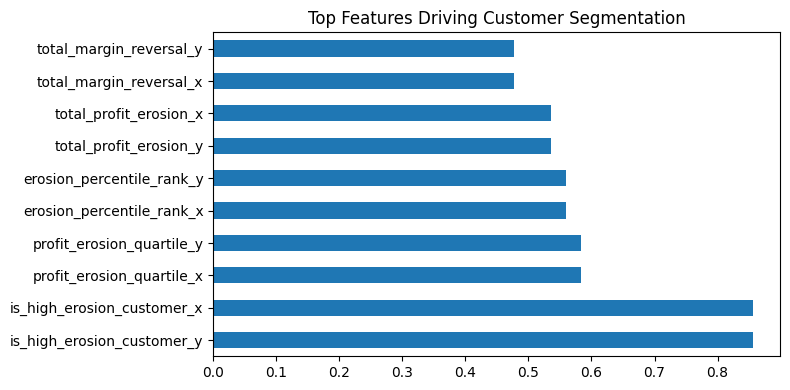

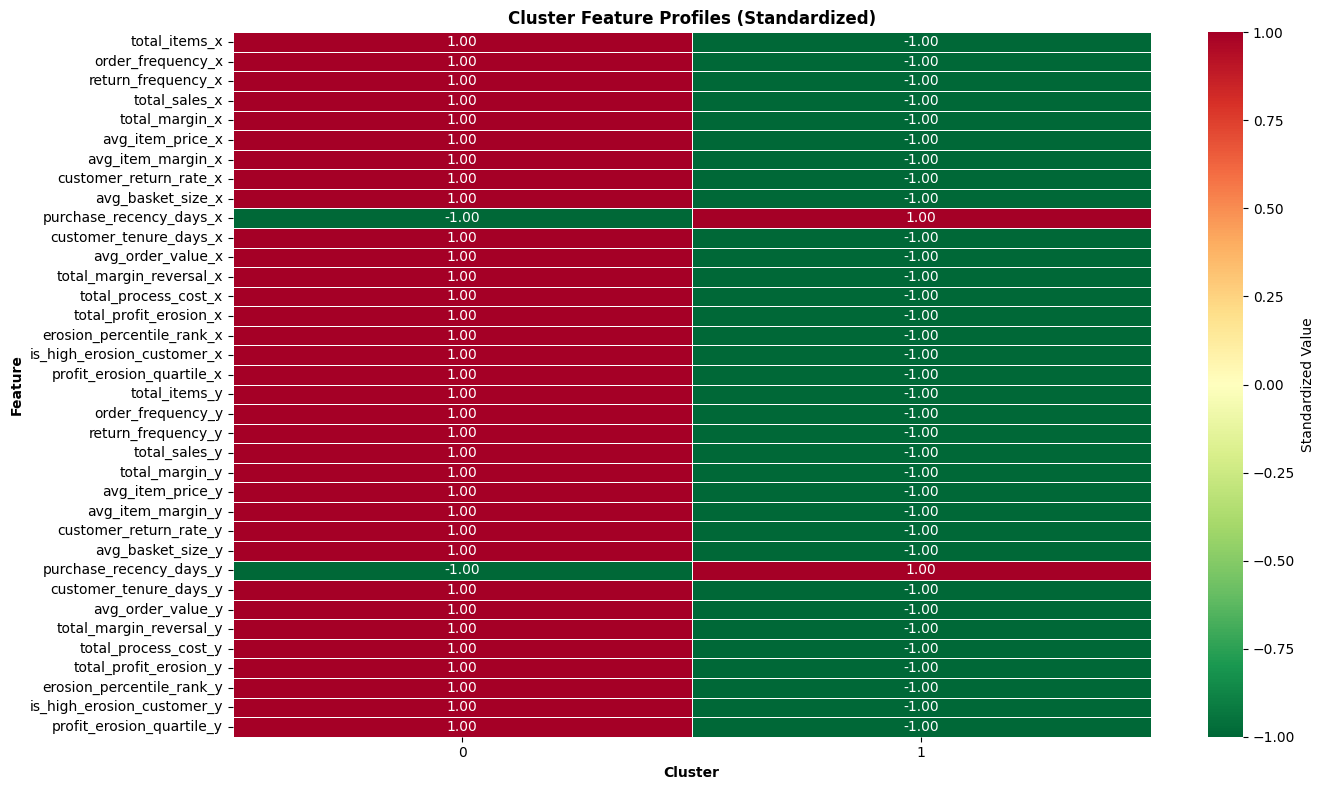

Saved feature importance and cluster heatmap figures


In [15]:
# Plot top features + standardized cluster heatmap
feature_importance_df.head(10).plot(
    kind='barh',
    figsize=(8, 4),
    legend=False,
    title='Top Features Driving Customer Segmentation'
)
plt.tight_layout()
plt.savefig(fig_dir / 'feature_importance_top10.png', dpi=150, bbox_inches='tight')
plt.show()

cluster_profiles = segmentation_df.groupby('cluster')[used_feature_cols].mean()
profiles_normalized = cluster_profiles.copy()
for col in profiles_normalized.columns:
    scaler = StandardScaler()
    profiles_normalized[col] = scaler.fit_transform(profiles_normalized[[col]])

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    profiles_normalized.T,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    cbar_kws={'label': 'Standardized Value'},
    linewidths=0.5,
    ax=ax
)
ax.set_xlabel('Cluster', fontweight='bold')
ax.set_ylabel('Feature', fontweight='bold')
ax.set_title('Cluster Feature Profiles (Standardized)', fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / 'cluster_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved feature importance and cluster heatmap figures')


## Step 10: Persist Segmentation Metadata and Results

Key outputs saved include:
- Cluster assignments
- Summary statistics
- Diagnostic metrics

All outputs are written to version-controlled directories to support
academic reproducibility and CI execution.


In [16]:
# Save metadata and summary
metadata = {
    'k_used': int(k_final),
    'feature_columns_used': used_feature_cols,
    'top_x': 0.2,
    'gini': float(gini),
    'top_10_share_of_erosion': float(top_10_share),
    'top_20_share_of_erosion': float(top_20_share),
    'top_50_share_of_erosion': float(top_50_share),
    'final_silhouette': float(final_silhouette),
    'final_calinski_harabasz': float(final_calinski),
    'final_davies_bouldin': float(final_davies),
}

with open(rq2_output_dir / 'rq2_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

summary = {
    'customers': int(len(customer_erosion)),
    'total_profit_erosion': float(customer_erosion['total_profit_erosion'].sum()),
    'gini': float(gini),
    'top_20_share_of_erosion': float(top_20_share),
    'k_used': int(k_final),
}

with open(rq2_output_dir / 'rq2_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print(f'Saved metadata and summary (k={k_final})')


Saved metadata and summary (k=2)


## Visualization Outputs

The following section generates all RQ2 visualizations, including:
- Concentration curves
- Clustering diagnostics

Figures are saved programmatically to ensure consistency between
local and CI environments.

## Plot 1: Pareto Curve of Profit Erosion

This plot visualizes the cumulative share of total profit erosion
attributed to the top-ranked customers.

It directly answers whether a small fraction of customers drives
a disproportionate share of erosion.


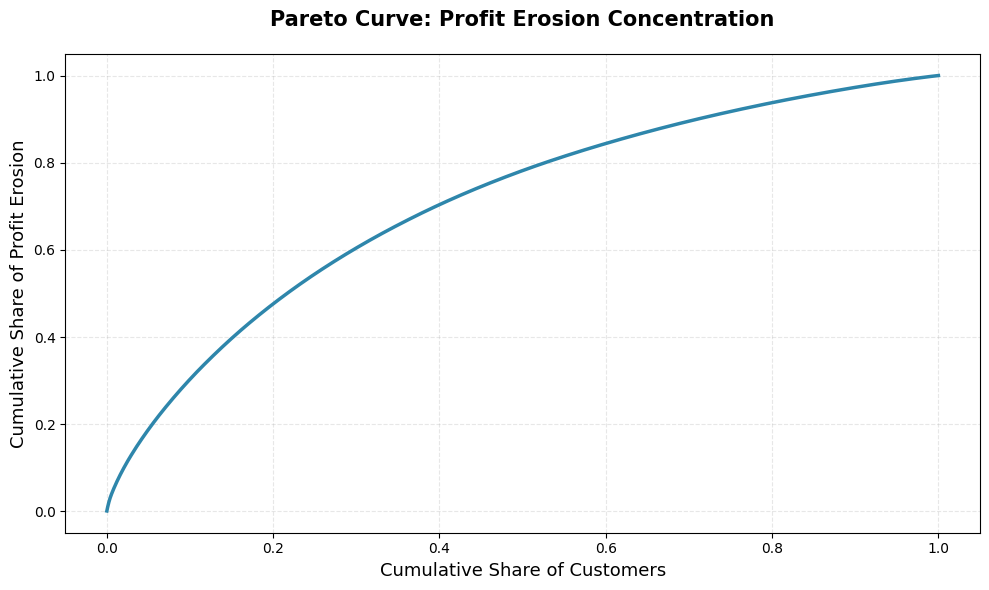

✓ Saved: pareto_curve.png


In [17]:
# PLOT 1: Pareto Curve
plt.figure(figsize=(10, 6))
plt.plot(pareto['customer_share'], pareto['value_share'], linewidth=2.5, color='#2E86AB')
plt.xlabel('Cumulative Share of Customers', fontsize=13)
plt.ylabel('Cumulative Share of Profit Erosion', fontsize=13)
plt.title('Pareto Curve: Profit Erosion Concentration', fontsize=15, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(fig_dir / 'pareto_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: pareto_curve.png")

## Plot 2: Lorenz Curve

The Lorenz curve provides a graphical representation of inequality
in profit erosion distribution across customers.

Greater curvature indicates stronger concentration effects.

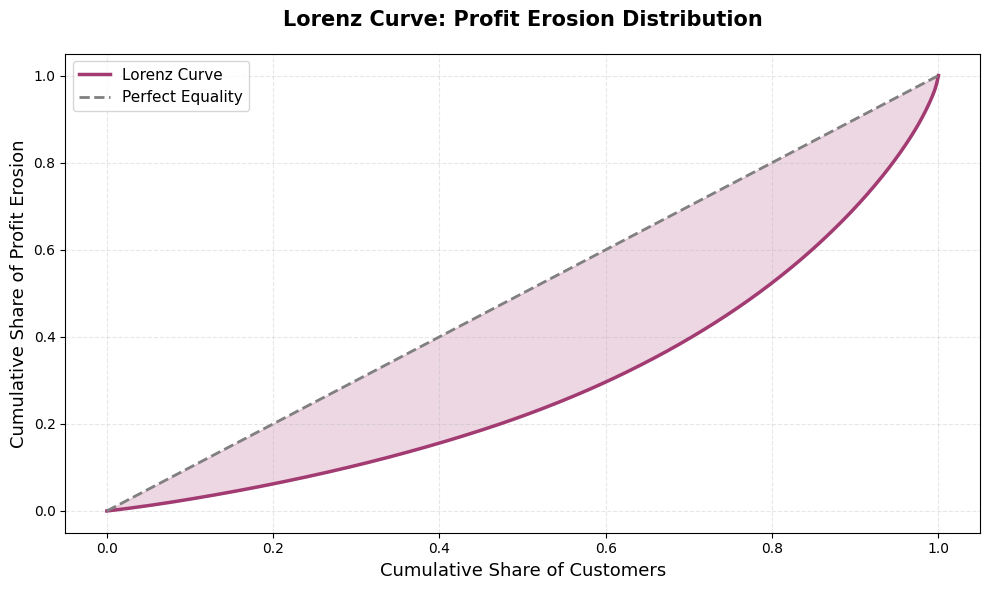

✓ Saved: lorenz_curve.png


In [18]:
# PLOT 2: Lorenz Curve
plt.figure(figsize=(10, 6))
plt.plot(lorenz['population_share'], lorenz['value_share'], linewidth=2.5, color='#A23B72', label='Lorenz Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2, label='Perfect Equality')
plt.fill_between(lorenz['population_share'], lorenz['value_share'], lorenz['population_share'], alpha=0.2, color='#A23B72')
plt.xlabel('Cumulative Share of Customers', fontsize=13)
plt.ylabel('Cumulative Share of Profit Erosion', fontsize=13)
plt.title('Lorenz Curve: Profit Erosion Distribution', fontsize=15, fontweight='bold', pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(fig_dir / 'lorenz_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: lorenz_curve.png")

## Plot 3: Clustering Metrics Comparison

This plot compares four diagnostics simultaneously to support a more defensible K selection.

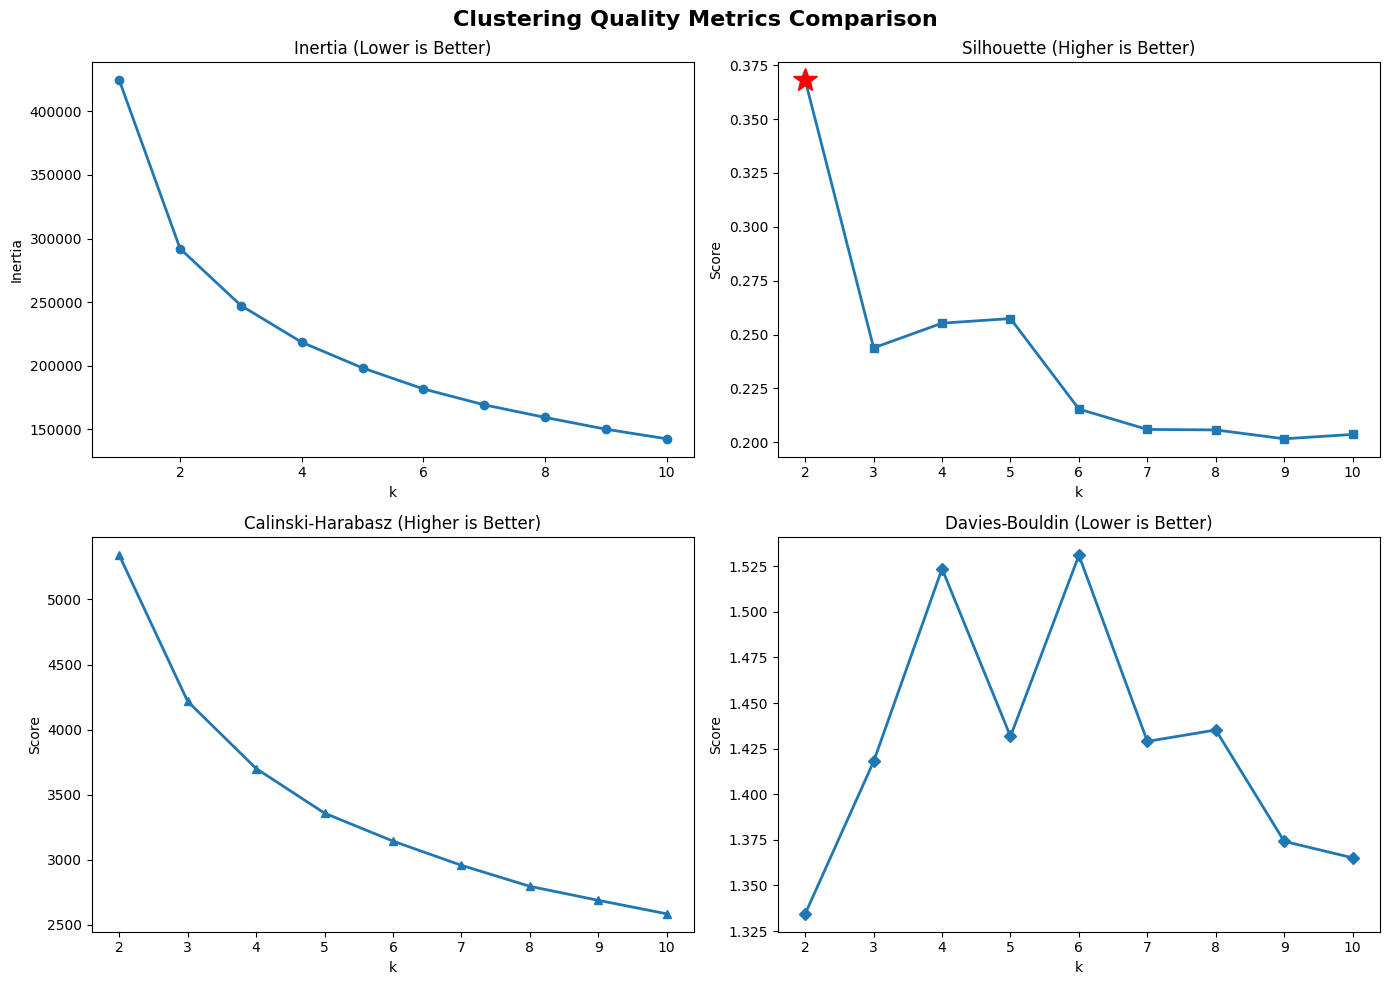

Saved: clustering_metrics_comparison.png


In [19]:
# PLOT 3: Clustering Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df['k'], metrics_df['inertia'], marker='o', linewidth=2)
axes[0, 0].set_title('Inertia (Lower is Better)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(metrics_df['k'], metrics_df['silhouette'], marker='s', linewidth=2)
axes[0, 1].set_title('Silhouette (Higher is Better)')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Score')
axes[0, 1].plot(k_final, best_sil, 'r*', markersize=18)

valid_metrics = metrics_df[metrics_df['k'] >= 2]
axes[1, 0].plot(valid_metrics['k'], valid_metrics['calinski_harabasz'], marker='^', linewidth=2)
axes[1, 0].set_title('Calinski-Harabasz (Higher is Better)')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Score')

axes[1, 1].plot(valid_metrics['k'], valid_metrics['davies_bouldin'], marker='D', linewidth=2)
axes[1, 1].set_title('Davies-Bouldin (Lower is Better)')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Score')

plt.suptitle('Clustering Quality Metrics Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / 'clustering_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: clustering_metrics_comparison.png')


## Plot 4: Silhouette Score Analysis

Silhouette scores measure how well each customer fits within its
assigned cluster relative to other clusters.

Higher average scores indicate better-defined segmentation.


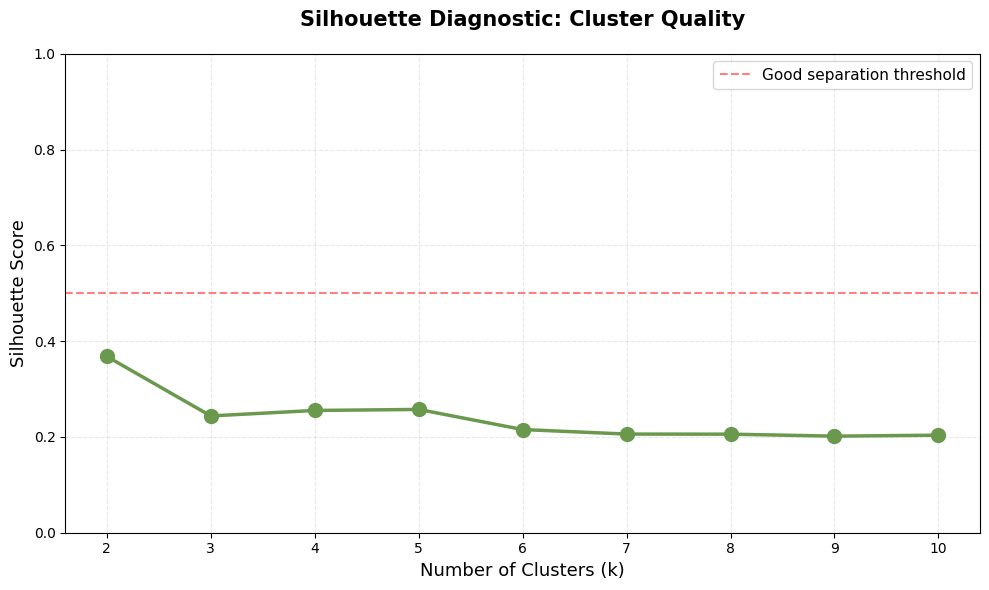

✓ Saved: silhouette_scores.png


In [20]:
# PLOT 4: Silhouette Scores
plt.figure(figsize=(10, 6))
# silhouette_df was already created and defined in Cell 9
plt.plot(silhouette_df['k'], silhouette_df['silhouette'], marker='o', linewidth=2.5, markersize=10, color='#6A994E')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Good separation threshold')
plt.xlabel('Number of Clusters (k)', fontsize=13)
plt.ylabel('Silhouette Score', fontsize=13)
plt.title('Silhouette Diagnostic: Cluster Quality', fontsize=15, fontweight='bold', pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(fig_dir / 'silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: silhouette_scores.png")

## Step 11: Boxplot Analysis of Customer Profit Erosion

This boxplot visualizes the distribution of **customer-level profit erosion**
across all customers.

The plot highlights:
- Median profit erosion
- Interquartile range (IQR)
- Presence of extreme outliers

This visualization helps identify whether profit erosion is driven by
a small number of high-impact customers, complementing the earlier
concentration metrics (Pareto, Lorenz, Gini).


✓ Found column: total_profit_erosion_x


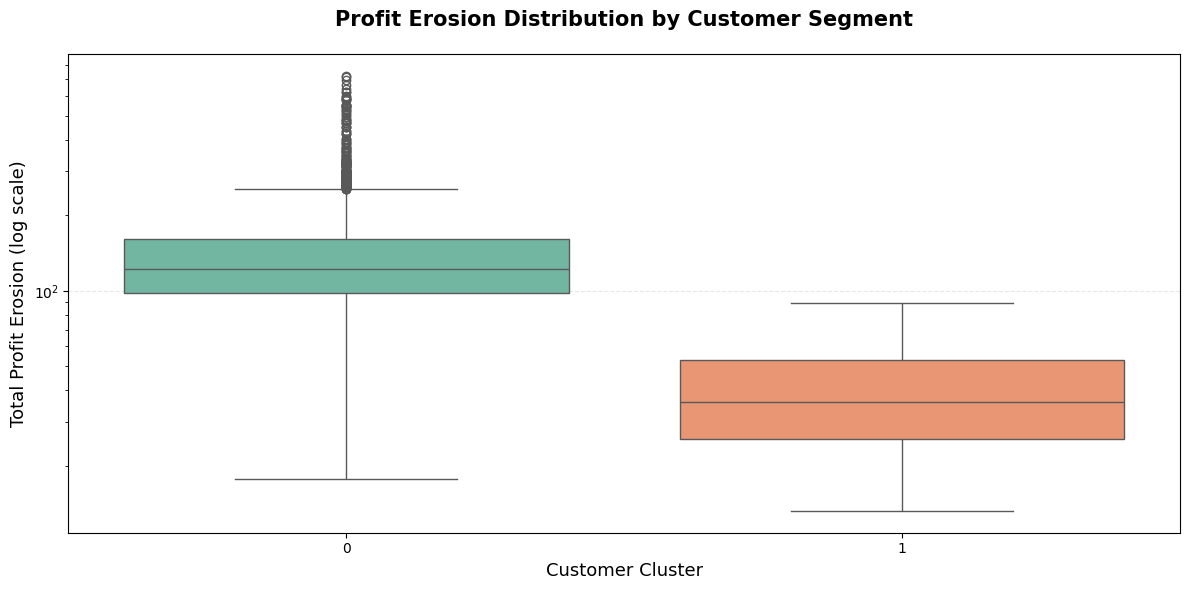

✓ Saved: cluster_boxplot.png


In [21]:
# 1. Identify the correct erosion column name dynamically
# Look for 'total_profit_erosion', or anything containing 'profit_erosion'
erosion_col = 'total_profit_erosion'
if erosion_col not in seg_table.columns:
    similar_cols = [c for c in seg_table.columns if 'profit_erosion' in c]
    if similar_cols:
        erosion_col = similar_cols[0]
        print(f"✓ Found column: {erosion_col}")
    else:
        # If still not found, print columns to help you debug
        print(f"❌ Error: Could not find erosion column. Available: {seg_table.columns.tolist()}")

# 2. PLOT 5: Cluster Boxplot
plt.figure(figsize=(12, 6))

# Only plot if we found the column
if erosion_col in seg_table.columns:
    sns.boxplot(
        data=seg_table, 
        x='cluster', 
        y=erosion_col, 
        hue='cluster', 
        palette='Set2', 
        legend=False
    )
    
    # Use log scale to handle the wide range of erosion values (from $15 to $700+)
    plt.yscale('log')
    
    plt.xlabel('Customer Cluster', fontsize=13)
    plt.ylabel('Total Profit Erosion (log scale)', fontsize=13)
    plt.title('Profit Erosion Distribution by Customer Segment', fontsize=15, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, axis='y', linestyle='--')
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(fig_dir / 'cluster_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: cluster_boxplot.png")

## Step 12: Console Summary and Sanity Checks

This cell prints a structured console summary of:
- Key metrics
- Dataset dimensions
- Final validation checks

These outputs support rapid debugging and peer review.


In [22]:
print("\n" + "="*70)
print("CLUSTER SUMMARY STATISTICS")
print("="*70)

# 1. Map columns dynamically to handle naming variations
def find_col(possible_names):
    for name in possible_names:
        if name in seg_table.columns:
            return name
    return None

# Find the best matches for our required metrics
erosion_col = find_col(['total_profit_erosion', 'profit_erosion', 'total_profit_erosion_x'])
return_col  = find_col(['customer_return_rate', 'return_rate', 'avg_return_rate'])
freq_col    = find_col(['order_frequency', 'num_orders', 'total_orders'])
sales_col   = find_col(['total_sales', 'total_sales_x', 'revenue'])

# 2. Build the aggregation dictionary only with columns that exist
agg_dict = {'user_id': 'count'}
col_names = ['Count']

if erosion_col:
    agg_dict[erosion_col] = ['sum', 'mean', 'median']
    col_names.extend(['Total_Erosion', 'Mean_Erosion', 'Median_Erosion'])
if return_col:
    agg_dict[return_col] = 'mean'
    col_names.append('Avg_Return_Rate')
if freq_col:
    agg_dict[freq_col] = 'mean'
    col_names.append('Avg_Orders')
if sales_col:
    agg_dict[sales_col] = 'mean'
    col_names.append('Avg_Sales')

# 3. Perform the aggregation
cluster_summary = seg_table.groupby('cluster').agg(agg_dict).round(2)
cluster_summary.columns = col_names

print(cluster_summary)

# Save cluster summary
cluster_summary.to_csv(rq2_output_dir / 'cluster_summary.csv')
print(f"\n✓ Saved cluster_summary.csv to {rq2_output_dir}")


CLUSTER SUMMARY STATISTICS
         Count  Total_Erosion  Mean_Erosion  Median_Erosion  Avg_Sales
cluster                                                               
0         3302      463323.41        140.32          122.12     318.05
1         8488      344928.66         40.64           35.93     117.08

✓ Saved cluster_summary.csv to c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project\data\processed\rq2


## Final RQ2 Summary

This notebook completes the RQ2 analysis by:
- Quantifying customer-level profit erosion concentration
- Demonstrating whether meaningful customer segments exist
- Providing evidence to support downstream predictive modeling (RQ3)

All results are reproducible, CI-safe, and aligned with the Capstone research framework.


In [23]:
# Interim summary (additional robustness and significance outputs are generated below)
print('\n' + '='*70)
print('RQ2 CORE ANALYSIS COMPLETE')
print('='*70)
print(f'Customers analyzed: {len(customer_erosion):,}')
print(f'Total profit erosion: ${customer_erosion["total_profit_erosion"].sum():,.2f}')
print(f'Gini coefficient: {gini:.3f}')
print(f'Top 20% share: {top_20_share*100:.1f}%')
print(f'Clusters (k): {k_final}')
print(f'Final silhouette: {final_silhouette:.4f}')
print('='*70)



RQ2 CORE ANALYSIS COMPLETE
Customers analyzed: 11,790
Total profit erosion: $808,252.07
Gini coefficient: 0.412
Top 20% share: 47.6%
Clusters (k): 2
Final silhouette: 0.3680


## Step 9B: Cluster Stability and Robustness (Bootstrap)

This robustness check evaluates whether the K-Means segmentation is stable under resampling.
We use bootstrap resampling of customers, refit K-Means with the selected K, and compare
cluster assignments to the baseline using Adjusted Rand Index (ARI).

- ARI close to 1.0 indicates highly consistent segmentation.
- Lower ARI indicates sensitivity to sampling/initialization.


Running bootstrap stability check (B=50, K=2)...
  Progress: 10/50 iterations complete
  Progress: 20/50 iterations complete
  Progress: 30/50 iterations complete
  Progress: 40/50 iterations complete
  Progress: 50/50 iterations complete
Bootstrap ARI (vs baseline):
  mean=0.9941, std=0.0043
  min=0.9845, max=0.9989
Stability rating: EXCELLENT
Interpretation: Clustering is highly stable and reproducible.


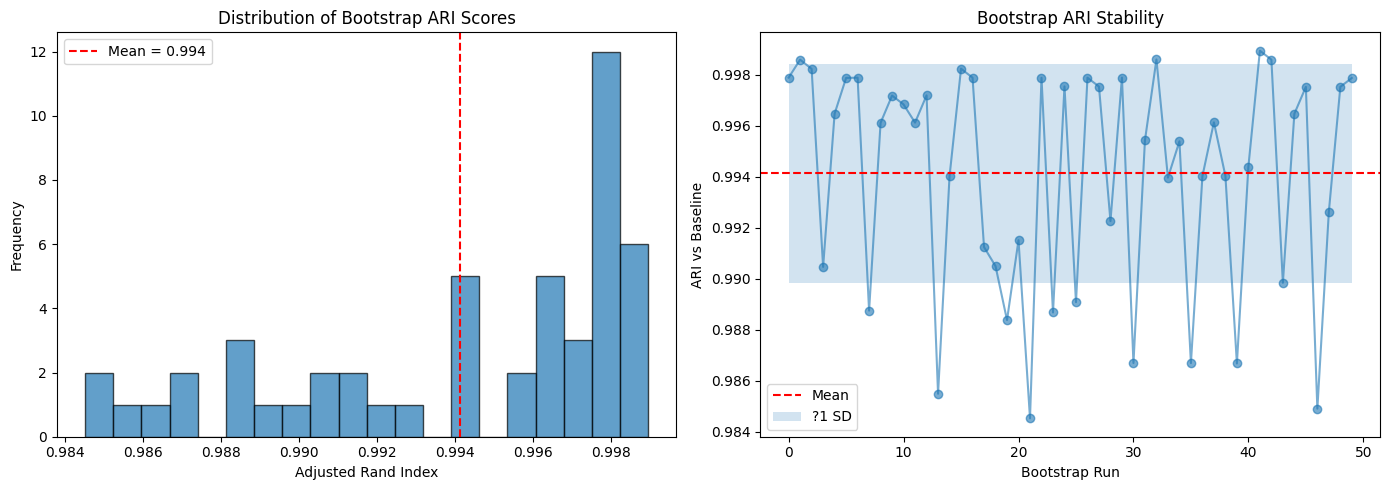

Saved: cluster_stability_bootstrap.csv and bootstrap_stability.png


In [24]:
# --- Bootstrap stability and robustness ---
B = 50
n = X_scaled.shape[0]
baseline_labels = final_labels.copy()
ari_scores = []

print(f'Running bootstrap stability check (B={B}, K={k_final})...')
for b in range(B):
    idx = resample(np.arange(n), replace=True, n_samples=n, random_state=b)
    X_boot = X_scaled[idx]

    km_boot = KMeans(n_clusters=k_final, random_state=b, n_init=10)
    boot_labels = km_boot.fit_predict(X_boot)

    ari = adjusted_rand_score(baseline_labels[idx], boot_labels)
    ari_scores.append(ari)

    if (b + 1) % 10 == 0:
        print(f'  Progress: {b + 1}/{B} iterations complete')

ari_scores = np.array(ari_scores)
mean_ari = float(ari_scores.mean())
std_ari = float(ari_scores.std())

if mean_ari >= 0.9:
    stability_rating = 'EXCELLENT'
    stability_interpretation = 'Clustering is highly stable and reproducible.'
elif mean_ari >= 0.75:
    stability_rating = 'GOOD'
    stability_interpretation = 'Clustering is reasonably stable.'
elif mean_ari >= 0.6:
    stability_rating = 'MODERATE'
    stability_interpretation = 'Clustering shows moderate stability; consider more data or alternate K.'
else:
    stability_rating = 'POOR'
    stability_interpretation = 'Clustering is unstable; segment assignments may be unreliable.'

print('Bootstrap ARI (vs baseline):')
print(f'  mean={mean_ari:.4f}, std={std_ari:.4f}')
print(f'  min={ari_scores.min():.4f}, max={ari_scores.max():.4f}')
print(f'Stability rating: {stability_rating}')
print(f'Interpretation: {stability_interpretation}')

stability_df = pd.DataFrame({'bootstrap_run': range(B), 'ari_vs_baseline': ari_scores})
stability_df.to_csv(rq2_output_dir / 'cluster_stability_bootstrap.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(ari_scores, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(mean_ari, color='red', linestyle='--', label=f'Mean = {mean_ari:.3f}')
axes[0].set_xlabel('Adjusted Rand Index')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Bootstrap ARI Scores')
axes[0].legend()

axes[1].plot(range(B), ari_scores, marker='o', alpha=0.6)
axes[1].axhline(mean_ari, color='red', linestyle='--', label='Mean')
axes[1].fill_between(range(B), mean_ari - std_ari, mean_ari + std_ari, alpha=0.2, label='?1 SD')
axes[1].set_xlabel('Bootstrap Run')
axes[1].set_ylabel('ARI vs Baseline')
axes[1].set_title('Bootstrap ARI Stability')
axes[1].legend()

plt.tight_layout()
plt.savefig(fig_dir / 'bootstrap_stability.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: cluster_stability_bootstrap.csv and bootstrap_stability.png')


## Segment Significance Testing (RQ2 Segments vs Outcome)

This section tests whether profit erosion differs across clusters, quantifies effect size, and runs post-hoc pairwise comparisons when needed.

In [25]:
# --- Prepare segmentation table for significance testing ---
assert 'user_id' in segmentation_df.columns, 'segmentation_df missing user_id'
assert 'cluster' in segmentation_df.columns, 'Cluster labels not attached to segmentation_df'

if 'total_profit_erosion' not in segmentation_df.columns:
    assert 'user_id' in customer_erosion.columns, 'customer_erosion missing user_id'
    segmentation_df = segmentation_df.merge(
        customer_erosion[['user_id', 'total_profit_erosion']],
        on='user_id',
        how='left',
        validate='1:1'
    )

missing = int(segmentation_df['total_profit_erosion'].isna().sum())
print('Prepared segmentation_df for significance testing')
print(f'  Missing total_profit_erosion values: {missing}')


Prepared segmentation_df for significance testing
  Missing total_profit_erosion values: 0


In [26]:
# --- Statistical significance tests + effect sizes + post-hoc ---
outcome_col = 'total_profit_erosion'
cluster_ids = sorted(segmentation_df['cluster'].unique())
cluster_groups = [
    segmentation_df.loc[segmentation_df['cluster'] == c, outcome_col].values
    for c in cluster_ids
]

normality_pvals = []
all_normal = True
for i, group in enumerate(cluster_groups):
    if len(group) < 3:
        p = 0.0
    elif len(group) > 5000:
        print(f'Warning: cluster {cluster_ids[i]} has n={len(group)}; Shapiro may be oversensitive on large samples.')
        sample_group = np.random.default_rng(42).choice(group, size=5000, replace=False)
        p = stats.shapiro(sample_group)[1]
    else:
        p = stats.shapiro(group)[1]
    normality_pvals.append(float(p))
    all_normal = all_normal and (p > 0.05)

if all_normal:
    stat, p_value = stats.f_oneway(*cluster_groups)
    test_name = 'One-way ANOVA'
else:
    stat, p_value = stats.kruskal(*cluster_groups)
    test_name = 'Kruskal-Wallis'

is_significant = bool(p_value < 0.05)

all_erosion = segmentation_df[outcome_col].values
grand_mean = all_erosion.mean()
ss_between = sum(len(group) * (group.mean() - grand_mean) ** 2 for group in cluster_groups)
ss_total = np.sum((all_erosion - grand_mean) ** 2)
eta_squared = float(ss_between / ss_total) if ss_total > 0 else 0.0

if eta_squared < 0.01:
    effect_interpretation = 'Negligible'
elif eta_squared < 0.06:
    effect_interpretation = 'Small'
elif eta_squared < 0.14:
    effect_interpretation = 'Medium'
else:
    effect_interpretation = 'Large'

print(f'Test used: {test_name}')
print(f'Statistic: {stat:.4f}')
print(f'P-value: {p_value:.6f}')
print(f'Eta-squared: {eta_squared:.4f} ({effect_interpretation})')
print(f'Variance explained by clusters: {eta_squared * 100:.2f}%')

significance_summary = pd.DataFrame([{
    'test_name': test_name,
    'statistic': float(stat),
    'p_value': float(p_value),
    'is_significant': is_significant,
    'eta_squared': eta_squared,
    'effect_size': effect_interpretation,
}])
significance_summary.to_csv(rq2_output_dir / 'segment_significance_summary.csv', index=False)

posthoc_results = []
if is_significant and len(cluster_ids) > 2:
    n_comparisons = len(list(combinations(cluster_ids, 2)))
    bonferroni_alpha = 0.05 / n_comparisons

    for c1, c2 in combinations(cluster_ids, 2):
        group1 = segmentation_df.loc[segmentation_df['cluster'] == c1, outcome_col].values
        group2 = segmentation_df.loc[segmentation_df['cluster'] == c2, outcome_col].values

        if all_normal:
            pair_stat, pair_p = ttest_ind(group1, group2, equal_var=False)
            pair_test = 't-test'
        else:
            pair_stat, pair_p = mannwhitneyu(group1, group2, alternative='two-sided')
            pair_test = 'Mann-Whitney U'

        mean1, mean2 = group1.mean(), group2.mean()
        std_pooled = np.sqrt((group1.std() ** 2 + group2.std() ** 2) / 2)
        cohens_d = float((mean1 - mean2) / std_pooled) if std_pooled > 0 else 0.0

        posthoc_results.append({
            'cluster_1': int(c1),
            'cluster_2': int(c2),
            'test_type': pair_test,
            'statistic': float(pair_stat),
            'p_value': float(pair_p),
            'bonferroni_alpha': float(bonferroni_alpha),
            'significant': bool(pair_p < bonferroni_alpha),
            'cohens_d': cohens_d,
            'mean_diff': float(mean1 - mean2),
        })

    posthoc_df = pd.DataFrame(posthoc_results)
    posthoc_df.to_csv(rq2_output_dir / 'posthoc_tests.csv', index=False)
    print(f'Saved post-hoc tests with Bonferroni alpha={bonferroni_alpha:.6f}')
else:
    pd.DataFrame(posthoc_results).to_csv(rq2_output_dir / 'posthoc_tests.csv', index=False)
    print('Post-hoc testing skipped (non-significant omnibus test or <=2 clusters).')

rq2_comprehensive_summary = {
    'concentration': {
        'gini_coefficient': float(gini),
        'top_10_pct_share': float(top_10_share),
        'top_20_pct_share': float(top_20_share),
        'top_50_pct_share': float(top_50_share),
        'total_customers_analyzed': int(len(customer_erosion)),
        'total_erosion': float(customer_erosion['total_profit_erosion'].sum()),
    },
    'segmentation': {
        'k_final': int(k_final),
        'selection_method': 'silhouette_score',
        'silhouette_score': float(final_silhouette),
        'calinski_harabasz': float(final_calinski),
        'davies_bouldin': float(final_davies),
        'cluster_sizes': {int(k): int(v) for k, v in seg_table['cluster'].value_counts().sort_index().items()},
    },
    'stability': {
        'mean_ari': float(mean_ari),
        'std_ari': float(std_ari),
        'stability_rating': stability_rating,
        'n_bootstrap_runs': int(B),
    },
    'significance': {
        'test_name': test_name,
        'p_value': float(p_value),
        'is_significant': bool(is_significant),
        'eta_squared': float(eta_squared),
        'effect_size': effect_interpretation,
    },
    'metadata': {
        'analysis_date': pd.Timestamp.now().isoformat(),
        'n_features': int(len(used_feature_cols)),
        'random_state': 42,
    },
}

with open(rq2_output_dir / 'rq2_comprehensive_summary.json', 'w', encoding='utf-8') as f:
    json.dump(rq2_comprehensive_summary, f, indent=2)

print('Saved segment_significance_summary.csv, posthoc_tests.csv, rq2_comprehensive_summary.json')


Test used: Kruskal-Wallis
Statistic: 6602.4714
P-value: 0.000000
Eta-squared: 0.5350 (Large)
Variance explained by clusters: 53.50%
Post-hoc testing skipped (non-significant omnibus test or <=2 clusters).
Saved segment_significance_summary.csv, posthoc_tests.csv, rq2_comprehensive_summary.json


## Business Insights and Recommendations

### Key Findings
- Profit erosion is concentrated (high Gini and top-share concentration metrics).
- Clusters show statistically testable differences in erosion outcomes.
- Effect size and bootstrap ARI indicate practical reliability of segmentation.

### Recommended Actions
1. Prioritize high-erosion segments for proactive interventions and return-prevention playbooks.
2. Use low-erosion segments as behavioral benchmarks for acquisition and retention targeting.
3. Allocate operations and customer support effort proportionally to segment-level erosion risk.
4. Track segment migration monthly and re-estimate clustering/stability on new data.